# Примеры запросов при работе с базой данных **Chinook**

##  Подключаем необходимые модули

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown

In [2]:
db_path = Path(Path.cwd().parent) / "db/chinook.db"
if not db_path.exists():
    db_path = Path(Path.cwd().parent.parent.parent) / "db/chinook.db"
conn = sqlite3.connect(db_path)

In [3]:
def get_data(sql: str) -> pd.DataFrame:
    """Get data."""
    return pd.read_sql_query(sql, conn)

def display_data(data: pd.DataFrame, head: bool | int = False, index: bool = False) -> None:
    """Display data."""
    if head:
        display(Markdown(data.head(head).to_markdown(index=index)))
    else:
        display(Markdown(data.to_markdown(index=index)))

##  Выбрать все записи из таблицы `customer`
Запрос `SELECT * FROM customer LIMIT 5;` извлекает все столбцы из таблицы `customer` и возвращает первые 5 строк данных — остальные записи игнорируются.

In [4]:
sql = "SELECT FirstName, LastName, Company, Address  FROM customer;"
display_data(get_data(sql), 5)

| FirstName   | LastName    | Company                                          | Address                         |
|:------------|:------------|:-------------------------------------------------|:--------------------------------|
| Luís        | Gonçalves   | Embraer - Empresa Brasileira de Aeronáutica S.A. | Av. Brigadeiro Faria Lima, 2170 |
| Leonie      | Köhler      | nan                                              | Theodor-Heuss-Straße 34         |
| François    | Tremblay    | nan                                              | 1498 rue Bélanger               |
| Bjørn       | Hansen      | nan                                              | Ullevålsveien 14                |
| František   | Wichterlová | JetBrains s.r.o.                                 | Klanova 9/506                   |

##  Выбрать все записи из таблицы `customer` по определенным столбцам
Запрос `SELECT FirstName, LastName, Country FROM customer LIMIT 5;` извлекает из таблицы `customer` только три указанных столбца (`FirstName`, `LastName` и `Country`) и возвращает первые 5 строк данных — все остальные строки игнорируются благодаря ограничению `LIMIT 5`.

In [5]:
sql = "SELECT FirstName, LastName, Country FROM customer;"
display_data(get_data(sql), 5)

| FirstName   | LastName    | Country        |
|:------------|:------------|:---------------|
| Luís        | Gonçalves   | Brazil         |
| Leonie      | Köhler      | Germany        |
| François    | Tremblay    | Canada         |
| Bjørn       | Hansen      | Norway         |
| František   | Wichterlová | Czech Republic |

##  Посчитать кол-во клиентов каждой стране

Запрос `SELECT Country, COUNT(*) AS customer_count FROM customer GROUP BY Country ORDER BY customer_count DESC;` группирует записи из таблицы `customer` по столбцу `Country`, подсчитывает количество клиентов в каждой стране (`COUNT(*)` и присваивает результату псевдоним `customer_count`), а затем сортирует полученные данные по убыванию числа клиентов — так, что страна с наибольшим количеством клиентов оказывается первой в итоговом списке.

In [6]:
sql = """SELECT Country, Count(*) AS customer_count 
    FROM customer 
    GROUP BY Country 
    ORDER BY customer_count DESC;"""
display_data(data:=get_data(sql), 5)

| Country   |   customer_count |
|:----------|-----------------:|
| USA       |               13 |
| Canada    |                8 |
| France    |                5 |
| Brazil    |                5 |
| Germany   |                4 |

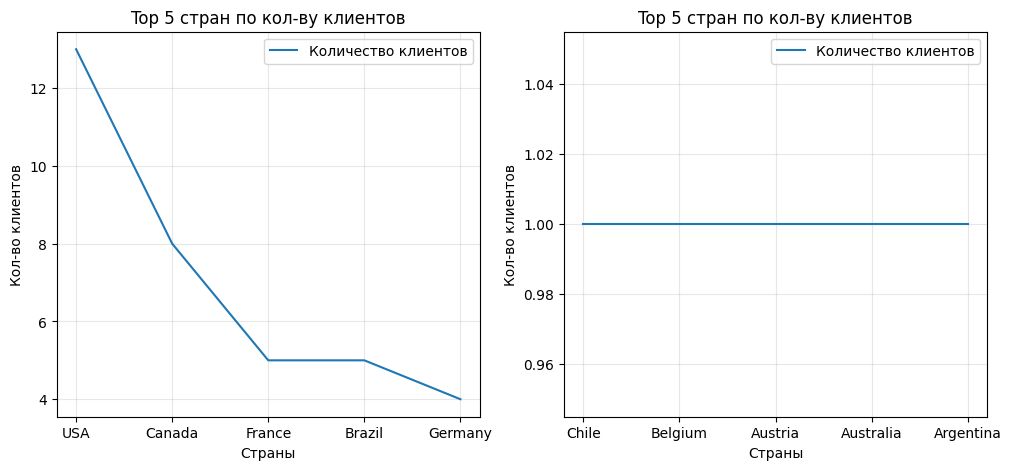

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(data["Country"].head(5), data["customer_count"].head(5), label="Количество клиентов")
ax1.set_ylabel("Кол-во клиентов")
ax1.set_xlabel("Страны")
ax1.set_title("Top 5 стран по кол-ву клиентов")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(data["Country"].tail(5), data["customer_count"].tail(5), label="Количество клиентов")
ax2.set_ylabel("Кол-во клиентов")
ax2.set_xlabel("Страны")
ax2.set_title("Top 5 стран по кол-ву клиентов")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

##  Отчёт по продажам с разбивкой по клиентам и ответственным сотрудникам

Запрос объединяет данные из таблиц `customer`, `employee` и `invoice`, формирует полные имена клиента (`CustomerName`) и ответственного сотрудника (`EmployeeName`), подсчитывает количество счетов‑фактур (`invoices`) и суммирует их общую стоимость (`total`) для каждого клиента. Результаты группируются по идентификатору клиента и данным сотрудника, а затем сортируются по убыванию общей суммы (`total`).

In [8]:
sql = """SELECT 
	c.FirstName || ' ' || c.LastName AS CustomerName,
	e.FirstName || ' ' || e.LastName AS EmployeeName, 
	COUNT(i.InvoiceId) AS invoices, 
	SUM(i.Total) AS total
FROM customer c
LEFT JOIN employee e ON c.SupportRepId = e.EmployeeId
LEFT JOIN invoice i ON i.CustomerId  = c.CustomerId 
GROUP BY c.CustomerId, e.FirstName, e.LastName
ORDER BY total DESC;"""
display_data(data:=get_data(sql), 5)

| CustomerName       | EmployeeName   |   invoices |   total |
|:-------------------|:---------------|-----------:|--------:|
| Helena Holý        | Steve Johnson  |          7 |   49.62 |
| Richard Cunningham | Margaret Park  |          7 |   47.62 |
| Luis Rojas         | Steve Johnson  |          7 |   46.62 |
| Ladislav Kovács    | Jane Peacock   |          7 |   45.62 |
| Hugh O'Reilly      | Jane Peacock   |          7 |   45.62 |

## Отчёт по продажам менеджеров (количество и сумма счетов)

Запрос извлекает данные о сотрудниках (формирует полное имя через объединение полей `FirstName` и `LastName` в `EmployeeName`), подсчитывает количество счетов‑фактур (`Invoices`) и суммирует их общую стоимость (`Total`) для каждого сотрудника — с учётом клиентов, закреплённых за ним в качестве менеджера поддержки. Для этого выполняются соединения таблиц `Employee`, `Customer` (по полю `SupportRepId`) и `Invoice` (по `CustomerId`). Результаты группируются по идентификатору сотрудника (`e.EmployeeId`) и сортируются по убыванию суммарной стоимости счетов (`Total`). Функция `COALESCE` гарантирует замену возможных значений `NULL` на `0` в колонках `Invoices` и `Total`.

In [9]:
sql = """SELECT 
	e.FirstName || ' ' || e.LastName AS EmployeeName,
	COALESCE(COUNT(i.InvoiceId), 0) AS Invoices,
	COALESCE(SUM(i.Total), 0) AS Total
FROM Employee e
LEFT JOIN Customer c ON c.SupportRepId = e.EmployeeId
LEFT JOIN Invoice i ON i.CustomerId  = c.CustomerId 
GROUP BY e.EmployeeId 
ORDER BY total DESC;"""
display_data(data:=get_data(sql))

| EmployeeName     |   Invoices |   Total |
|:-----------------|-----------:|--------:|
| Jane Peacock     |        146 |  833.04 |
| Margaret Park    |        140 |  775.4  |
| Steve Johnson    |        126 |  720.16 |
| Andrew Adams     |          0 |    0    |
| Nancy Edwards    |          0 |    0    |
| Michael Mitchell |          0 |    0    |
| Robert King      |          0 |    0    |
| Laura Callahan   |          0 |    0    |

## Ежемесячная статистика по продажам всех продуктов

Этот запрос извлекает агрегированную информацию о счетах (инвойсах) по месяцам: группирует записи по месяцам (`STRFTIME('%Y-%m', i.InvoiceDate)`), подсчитывает количество уникальных клиентов (`COUNT(c.CustomerId)`), общее количество счетов (`COUNT(i.InvoiceId)`) и суммарную стоимость счетов (`SUM(i.Total)`) для каждого месяца. Использует соединения: правое (`RIGHT JOIN`) между `Employee` и `Customer` по полю `SupportRepId`, левое (`LEFT JOIN`) между `Customer` и `Invoice` по `CustomerId`. Результаты сортируются по убыванию месяца (`InvoiceYear DESC`) и суммарной стоимости (`Total DESC`).

**Краткое название:** «Ежемесячная статистика по счетам» / «Monthly invoice stats»

In [10]:
sql = """SELECT
    STRFTIME('%Y-%m', i.InvoiceDate) AS InvoiceYear,
    COUNT(c.CustomerId) AS Customers,
    COUNT(i.InvoiceId) AS Invoices,
    SUM(i.Total) AS Total
FROM Employee e
RIGHT JOIN Customer c ON c.SupportRepId = e.EmployeeId
LEFT JOIN Invoice i ON i.CustomerId = c.CustomerId
GROUP BY STRFTIME('%Y-%m', i.InvoiceDate)
ORDER BY InvoiceYear DESC, Total DESC;
"""
display_data(data:=get_data(sql), 5)

| InvoiceYear   |   Customers |   Invoices |   Total |
|:--------------|------------:|-----------:|--------:|
| 2025-12       |           7 |          7 |   38.62 |
| 2025-11       |           7 |          7 |   49.62 |
| 2025-10       |           7 |          7 |   37.62 |
| 2025-09       |           7 |          7 |   37.62 |
| 2025-08       |           7 |          7 |   37.62 |

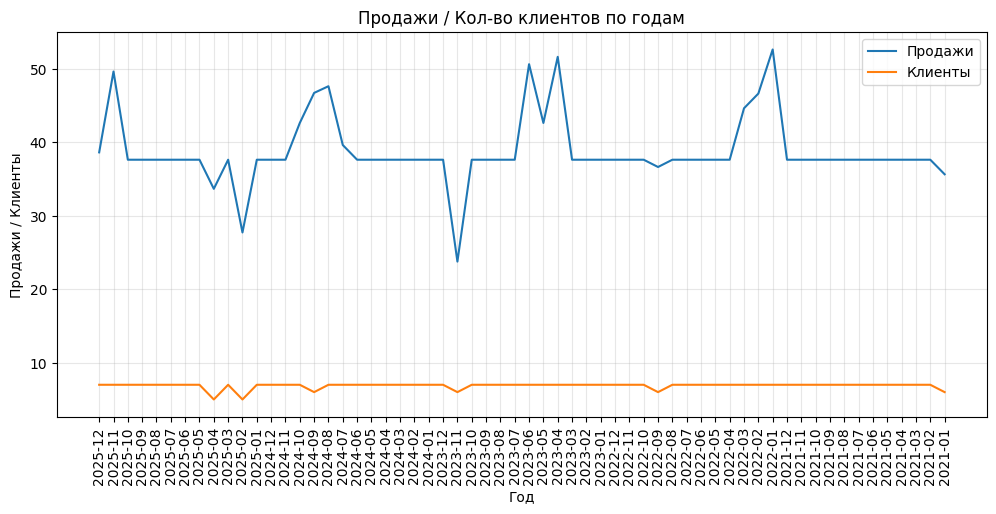

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(data["InvoiceYear"], data["Total"], label="Продажи")
plt.plot(data["InvoiceYear"], data["Customers"], label="Клиенты")

plt.xticks(rotation="vertical")
plt.grid(True, alpha=0.3)
plt.xlabel("Год")
plt.ylabel("Продажи / Клиенты")
plt.title("Продажи / Кол-во клиентов по годам")
plt.legend()

plt.show()

# Альбомы с наибольшей суммой продаж треков

**Описание запроса:**


Запрос извлекает название альбома (`Title`), подсчитывает количество треков в каждом альбоме (`track_count`) и вычисляет общую сумму продаж по всем заказам для треков этого альбома (`ammount`). Для этого он объединяет таблицы `InvoiceLine`, `Track` и `Album` через LEFT JOIN, группирует результаты по идентификатору альбома (`AlbumId`) и сортирует итоговую таблицу по сумме продаж в порядке убывания (от наибольшего к наименьшему).

In [12]:
sql = """SELECT 
	a.Title,
	COUNT(il.TrackId ) as track_count,
	SUM(il.UnitPrice * il.Quantity) as ammount
FROM InvoiceLine il 
LEFT JOIN Track t ON il.TrackId = t.TrackId
LEFT JOIN Album a ON t.AlbumId  = a.AlbumId 
GROUP BY a.AlbumId 
ORDER BY ammount DESC;
"""
display_data(get_data(sql), 5)

| Title                                    |   track_count |   ammount |
|:-----------------------------------------|--------------:|----------:|
| Battlestar Galactica (Classic), Season 1 |            18 |     35.82 |
| The Office, Season 3                     |            16 |     31.84 |
| Minha Historia                           |            27 |     26.73 |
| Lost, Season 2                           |            13 |     25.87 |
| Heroes, Season 1                         |            13 |     25.87 |

# Самые продаваемые альбомы: название, число проданных треков, выручка и её доля от общего объёма

**Описание в одном абзаце:**

Запрос формирует отчёт по продажам музыкальных альбомов: для каждого альбома выводит его название (`a.Title`), количество проданных треков (`track_count`), суммарную выручку от их продаж (`ammount`), а также процентную долю этой выручки от общей суммы продаж всех альбомов (`persent`, округлённую до двух знаков после запятой). Данные собираются через соединение таблиц `InvoiceLine`, `Track` и `Album`, группируются по идентификатору альбома (`a.AlbumId`), а итоговая выборка сортируется по убыванию процентной доли выручки.


In [13]:
sql = """SELECT 
	a.Title,
	COUNT(il.TrackId ) as track_count,
	SUM(il.UnitPrice * il.Quantity) as ammount,
	ROUND((SUM(il.UnitPrice * il.Quantity) * 100) / 
    	SUM(SUM(il.UnitPrice * il.Quantity)) OVER (), 2) as percent
FROM InvoiceLine il 
LEFT JOIN Track t ON il.TrackId = t.TrackId
LEFT JOIN Album a ON t.AlbumId  = a.AlbumId 
GROUP BY a.AlbumId 
ORDER BY percent DESC;
"""
display_data(get_data(sql), 5)

| Title                                    |   track_count |   ammount |   percent |
|:-----------------------------------------|--------------:|----------:|----------:|
| Battlestar Galactica (Classic), Season 1 |            18 |     35.82 |      1.54 |
| The Office, Season 3                     |            16 |     31.84 |      1.37 |
| Minha Historia                           |            27 |     26.73 |      1.15 |
| Greatest Hits                            |            26 |     25.74 |      1.11 |
| Heroes, Season 1                         |            13 |     25.87 |      1.11 |

# Отчёт по артистам: количество и длительность треков

Запрос выбирает имя артиста (`a.Name`), подсчитывает количество треков для каждого артиста (`track_count`) и суммирует их длительность в условных единицах (миллисекунды поделены на 36 000 — вероятно, попытка получить длительность в десятых долях часа), объединяя данные из таблиц `Artist`, `Album` и `Track` через `LEFT JOIN`. Результаты группируются по идентификатору артиста (`ArtistId`) и сортируются по количеству треков в порядке убывания.

In [14]:
sql = """SELECT
	a.Name, 
	COUNT(t.TrackId ) AS track_count,
	SUM(t.Milliseconds) / 60000 AS duration_min,
	(SUM(SUM(t.Milliseconds)) OVER () / SUM(COUNT(t.TrackId )) OVER ()) / 60000 as duration_avg_min
FROM Artist a 
LEFT JOIN Album a2 ON a.ArtistId = a2.ArtistId 
LEFT JOIN Track t ON a2.AlbumId = t.AlbumId 
WHERE t.Milliseconds > 0
GROUP BY a.ArtistId 
ORDER BY track_count DESC;
"""
display_data(data:=get_data(sql), 10)

| Name            |   track_count |   duration_min |   duration_avg_min |
|:----------------|--------------:|---------------:|-------------------:|
| Iron Maiden     |           213 |           1197 |                  6 |
| U2              |           135 |            590 |                  6 |
| Led Zeppelin    |           114 |            668 |                  6 |
| Metallica       |           112 |            648 |                  6 |
| Deep Purple     |            92 |            537 |                  6 |
| Lost            |            92 |           3971 |                  6 |
| Pearl Jam       |            67 |            275 |                  6 |
| Lenny Kravitz   |            57 |            251 |                  6 |
| Various Artists |            56 |            233 |                  6 |
| The Office      |            53 |           1248 |                  6 |

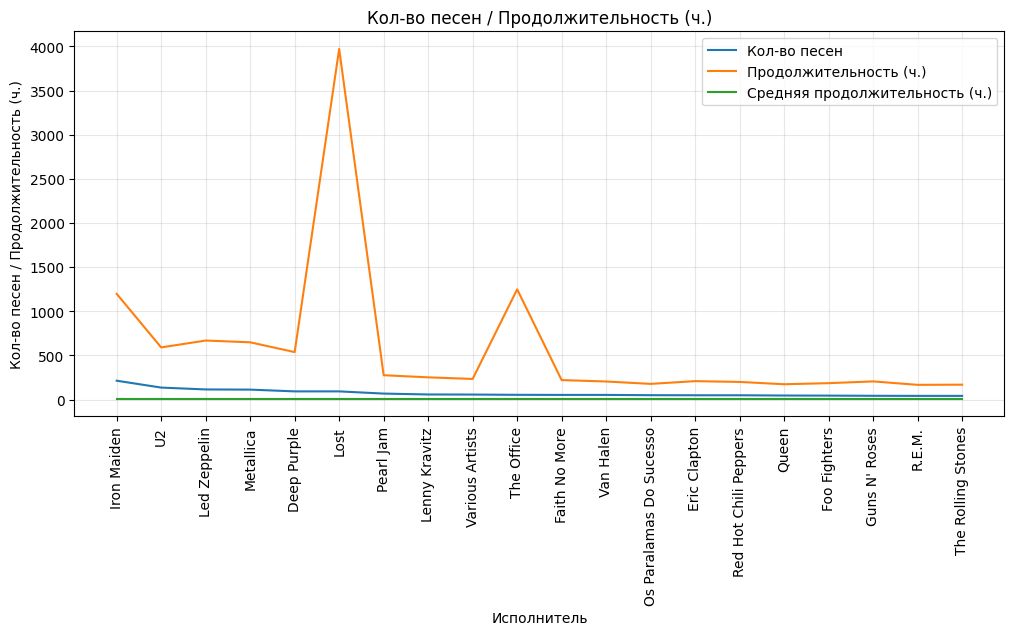

In [15]:
data = data.head(20)
plt.figure(figsize=(12, 5))
plt.plot(data["Name"], data["track_count"], label="Кол-во песен")
plt.plot(data["Name"], data["duration_min"], label="Продолжительность (ч.)")
plt.plot(data["Name"], data["duration_avg_min"], label="Средняя продолжительность (ч.)")

plt.xticks(rotation="vertical")
plt.grid(True, alpha=0.3)
plt.xlabel("Исполнитель")
plt.ylabel("Кол-во песен / Продолжительность (ч.)")
plt.title("Кол-во песен / Продолжительность (ч.)")
plt.legend()

plt.show()

# Top 10 артистов по продажам с разбивкой по годам

Сначала с помощью SQL‑запроса извлекает данные о продажах (включая дату счёта, город и страну оплаты, сумму, цену и количество единиц товара, название альбома, имя артиста и жанр); затем преобразует столбец `InvoiceDate` в год (формат `YYYY`); после этого создаёт сводную таблицу (`pivot_table`), где строки — имена артистов (`ArtistName`), столбцы — годы (`InvoiceDate`), а значения — суммарная выручка (`Total`) по каждому артисту за каждый год (с заполнением пропусков нулями и добавлением итоговой строки «Total»); наконец, отбирает топ‑10 артистов с наибольшей суммарной выручкой за весь период и сохраняет результат в переменную `top_10`.

In [16]:
sql = """SELECT
	i.InvoiceDate,
	i.BillingCity,
	i.BillingCountry,
	(il.UnitPrice * il.Quantity) AS Total,
	il.UnitPrice,
	il.Quantity,
	a.Title,
	ar.Name AS ArtistName,
	g.Name AS GengeName
FROM
	Invoice AS i
LEFT JOIN InvoiceLine AS il
  ON i.InvoiceId = il.InvoiceId
LEFT JOIN Track t 
  ON il.TrackId = t.TrackId
LEFT JOIN Genre g 
  ON t.GenreId = g.GenreId
LEFT JOIN Album a 
  ON t.AlbumId = a.AlbumId
LEFT JOIN Artist ar 
  ON a.ArtistId = ar.ArtistId;
"""

df = get_data(sql)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.strftime("%Y")

pivot = df.pivot_table(
    index="ArtistName",
    columns="InvoiceDate",
    values="Total",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Total"    
)
top_10 = pivot.nlargest(10, "Total")
top_10 = top_10.reset_index()
display_data(top_10, index=True)

|    | ArtistName              |   2021 |   2022 |   2023 |   2024 |   2025 |   Total |
|---:|:------------------------|-------:|-------:|-------:|-------:|-------:|--------:|
|  0 | Total                   | 449.46 | 481.45 | 469.58 | 477.53 | 450.58 | 2328.6  |
|  1 | Iron Maiden             |  33.66 |  34.65 |   0.99 |  33.66 |  35.64 |  138.6  |
|  2 | U2                      |   0    |  26.73 |  26.73 |  27.72 |  24.75 |  105.93 |
|  3 | Metallica               |  21.78 |  22.77 |   2.97 |  25.74 |  16.83 |   90.09 |
|  4 | Led Zeppelin            |  22.77 |  21.78 |   2.97 |  23.76 |  14.85 |   86.13 |
|  5 | Lost                    |   0    |  23.88 |  21.89 |  19.9  |  15.92 |   81.59 |
|  6 | The Office              |   0    |  11.94 |   9.95 |  25.87 |   1.99 |   49.75 |
|  7 | Os Paralamas Do Sucesso |   8.91 |   0.99 |  11.88 |  13.86 |   8.91 |   44.55 |
|  8 | Deep Purple             |  11.88 |  11.88 |   9.9  |   0    |   9.9  |   43.56 |
|  9 | Faith No More           |  15.84 |   9.9  |   8.91 |   0    |   6.93 |   41.58 |

# Top 10 жанров музыки по продажам с разбивкой по годам

Сначала с помощью SQL‑запроса извлекает данные о продажах (включая дату счёта, город и страну оплаты, сумму, цену и количество единиц товара, название альбома, имя артиста и жанр); затем преобразует столбец `InvoiceDate` в год (формат `YYYY`); после этого создаёт сводную таблицу (`pivot_table`), где строки — имена артистов (`GengeName`), столбцы — годы (`InvoiceDate`), а значения — суммарная выручка (`Total`) по каждому артисту за каждый год (с заполнением пропусков нулями и добавлением итоговой строки «Total»); наконец, отбирает топ‑10 артистов с наибольшей суммарной выручкой за весь период и сохраняет результат в переменную `top_10`.

In [17]:
sql = """SELECT
	i.InvoiceDate,
	i.BillingCity,
	i.BillingCountry,
	(il.UnitPrice * il.Quantity) AS Total,
	il.UnitPrice,
	il.Quantity,
	a.Title,
	ar.Name AS ArtistName,
	g.Name AS GengeName
FROM
	Invoice AS i
LEFT JOIN InvoiceLine AS il
  ON i.InvoiceId = il.InvoiceId
LEFT JOIN Track t 
  ON il.TrackId = t.TrackId
LEFT JOIN Genre g 
  ON t.GenreId = g.GenreId
LEFT JOIN Album a 
  ON t.AlbumId = a.AlbumId
LEFT JOIN Artist ar 
  ON a.ArtistId = ar.ArtistId;
"""

df = get_data(sql)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.strftime("%Y")

pivot = df.pivot_table(
    index="GengeName",
    columns="InvoiceDate",
    values="Total",
    aggfunc="sum",
    fill_value=0,
    margins=True,
    margins_name="Total"
)
top_10 = pivot.nlargest(10, "Total")
top_10 = top_10.reset_index()
display_data(top_10, index=True)

|    | GengeName          |   2021 |   2022 |   2023 |   2024 |   2025 |   Total |
|---:|:-------------------|-------:|-------:|-------:|-------:|-------:|--------:|
|  0 | Total              | 449.46 | 481.45 | 469.58 | 477.53 | 450.58 | 2328.6  |
|  1 | Rock               | 178.2  | 155.43 | 156.42 | 162.36 | 174.24 |  826.65 |
|  2 | Latin              |  82.17 |  77.22 |  80.19 |  63.36 |  79.2  |  382.14 |
|  3 | Metal              |  61.38 |  53.46 |  25.74 |  65.34 |  55.44 |  261.36 |
|  4 | Alternative & Punk |  62.37 |  39.6  |  45.54 |  38.61 |  55.44 |  241.56 |
|  5 | TV Shows           |   0    |  25.87 |  27.86 |  25.87 |  13.93 |   93.53 |
|  6 | Jazz               |  19.8  |  15.84 |  15.84 |   5.94 |  21.78 |   79.2  |
|  7 | Blues              |  10.89 |  10.89 |  19.8  |   8.91 |   9.9  |   60.39 |
|  8 | Drama              |   0    |  17.91 |  11.94 |  17.91 |   9.95 |   57.71 |
|  9 | Classical          |   0    |  13.86 |   9.9  |  16.83 |   0    |   40.59 |

# Расчет продаж по сотрудникам в абсалютном и процентном отношении 

Запрос формирует аналитическую сводку по продажам в разрезе сотрудников: объединяет имя и фамилию сотрудника в единое поле (FIO), подсчитывает количество обработанных каждым сотрудником счетов‑фактур (`InvoicesCount`) и суммарную выручку (`Salles`), а также выводит общие показатели по всей компании (`TotalInvoices` и `TotalSales`). Для каждого сотрудника рассчитываются доли от общих показателей — процент от общего числа счетов (`InvoicesPercentage`) и процент от общей выручки (`SalesPercentage`), — после чего результаты сортируются по убыванию доли выручки.

In [28]:
sql = """WITH SalesSummary AS (
    SELECT
        EmployeeId,
        LastName,
        FirstName,
        Title,
        COUNT(InvoiceId) AS Invoices,
        SUM(COUNT(InvoiceId)) OVER () AS TotalInvoices,
        IFNULL(SUM(Total), 0) AS Salles,
        SUM(SUM(Total)) OVER () AS TotalSales
    FROM (
        SELECT *
        FROM Employee e
        LEFT JOIN Customer c ON e.EmployeeId = c.SupportRepId
        LEFT JOIN Invoice i ON c.CustomerId = i.CustomerId
    ) src
    GROUP BY EmployeeId, LastName, FirstName, Title
)
SELECT
    FirstName || " " || LastName as FIO,
    Title AS Department,
    Invoices,
    Salles,
    ROUND((Invoices * 100.0 / TotalInvoices), 2) AS InvoicesPercentage,
    ROUND((Salles * 100.0 / TotalSales), 2) AS SalesPercentage,
    TotalInvoices,
    TotalSales
FROM SalesSummary
ORDER BY SalesPercentage DESC;"""

display_data(data:=get_data(sql))

| FIO              | Department          |   Invoices |   Salles |   InvoicesPercentage |   SalesPercentage |   TotalInvoices |   TotalSales |
|:-----------------|:--------------------|-----------:|---------:|---------------------:|------------------:|----------------:|-------------:|
| Jane Peacock     | Sales Support Agent |        146 |   833.04 |                35.44 |             35.77 |             412 |       2328.6 |
| Margaret Park    | Sales Support Agent |        140 |   775.4  |                33.98 |             33.3  |             412 |       2328.6 |
| Steve Johnson    | Sales Support Agent |        126 |   720.16 |                30.58 |             30.93 |             412 |       2328.6 |
| Andrew Adams     | General Manager     |          0 |     0    |                 0    |              0    |             412 |       2328.6 |
| Nancy Edwards    | Sales Manager       |          0 |     0    |                 0    |              0    |             412 |       2328.6 |
| Michael Mitchell | IT Manager          |          0 |     0    |                 0    |              0    |             412 |       2328.6 |
| Robert King      | IT Staff            |          0 |     0    |                 0    |              0    |             412 |       2328.6 |
| Laura Callahan   | IT Staff            |          0 |     0    |                 0    |              0    |             412 |       2328.6 |